# CIS*4020 — Assignment 1: Data Wrangling and Exploratory Data Analysis
## A completed sample report using OULAD

**Question:** How do recorded engagement and outcomes vary across course enrolments, and what can these observations tell us about equitable student support?

The unit of analysis is one **student–module–presentation enrolment**, not one unique person. This report completes the starter's Parts 1–5, including the attribute-type table, data-quality decisions, seven figures, five evidence-backed findings, reflection, and AI disclosure. All numerical results are calculated from the supplied CSV files.

## 0. Setup and data location

Keep this notebook in the project folder, with the seven CSVs in its **`content/` subfolder**. Run the notebook with the project folder as the working directory, or change `DATA_DIR` below to the directory containing the files. The files are already supplied here; execution does not download or modify them.

Required packages are Python, NumPy, pandas, Matplotlib, and IPython (normally available in Jupyter). `studentVle.csv` contains over ten million rows, so loading and grouping it needs sufficient memory. The two repeated course-code columns use categorical storage to reduce memory without changing their values; this storage choice does not determine their semantic attribute type.

The random seed is 42. No random sampling is used in the report, so every enrolment contributes to the summaries and figures.

In [1]:
from pathlib import Path
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
DATA_DIR = Path("content")  # Change this if the CSVs are stored elsewhere.
FILES = {
    "studentInfo": "studentInfo.csv",
    "studentRegistration": "studentRegistration.csv",
    "studentVle": "studentVle.csv",
    "vle": "vle.csv",
    "assessments": "assessments.csv",
    "studentAssessment": "studentAssessment.csv",
    "courses": "courses.csv",
}
KEYS = ["code_module", "code_presentation", "id_student"]
COURSE_KEYS = ["code_module", "code_presentation"]
OUTCOMES = ["Withdrawn", "Fail", "Pass", "Distinction"]
OUTCOME_COLORS = ["#D97732", "#B84A62", "#3975A5", "#399582"]
IMD_ORDER = [f"{i}-{i+10}%" for i in range(0, 100, 10)]
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 65)
pd.set_option("display.max_colwidth", 110)
plt.rcParams.update({
    "figure.figsize": (9, 5), "figure.dpi": 120,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.labelsize": 11,
})
versions = {"Python": platform.python_version(), "NumPy": np.__version__,
            "pandas": pd.__version__, "Matplotlib": matplotlib.__version__}
display(pd.Series(versions, name="Version").to_frame())

,Version
Python,3.14.8
NumPy,2.5.3
pandas,3.0.6
Matplotlib,3.11.2


### Read missing-value markers correctly

The supplied CSVs encode unknown values using **`?`**. Ordinary `read_csv` does not treat this token as missing, so `na_values=["?"]` is essential: otherwise dates and scores become text and missingness is understated. Default blank/NA parsing is retained as well. Raw tables remain available in `tables`; changes are made to copies or derived summaries.

In [2]:
missing_files = [filename for filename in FILES.values() if not (DATA_DIR / filename).is_file()]
if missing_files:
    raise FileNotFoundError(
        f"Missing files in {DATA_DIR.resolve()}: {missing_files}. "
        "Place the seven OULAD CSVs in content/ or update DATA_DIR."
    )

tables = {}
for name, filename in FILES.items():
    dtype = {"code_module": "category", "code_presentation": "category"} if name == "studentVle" else None
    tables[name] = pd.read_csv(DATA_DIR / filename, na_values=["?"], dtype=dtype)

file_inventory = pd.DataFrame([
    {"table": name, "rows": len(t), "columns": t.shape[1],
     "file_bytes": (DATA_DIR / FILES[name]).stat().st_size}
    for name, t in tables.items()
])
display(file_inventory)

,table,rows,columns,file_bytes
0,studentInfo,32593,12,3462763
1,studentRegistration,32593,5,1132550
2,studentVle,10655280,6,453836331
3,vle,6364,6,270612
4,assessments,206,6,8211
5,studentAssessment,173912,5,5690483
6,courses,22,3,526


## Part 1 — Acquire and understand

### 1a. Provenance, observation units, and relationships

OULAD was released by **Jakub Kuzilek, Martin Hlosta, and Zdenek Zdrahal** from The Open University. The repository records its donation in December 2015 and licenses it under **CC BY 4.0**. Attribution: Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2015), *Open University Learning Analytics dataset*, [UCI repository](https://archive.ics.uci.edu/dataset/349/open+university+learning+analytics+dataset), [dataset DOI](https://doi.org/10.24432/C5KK69). Field definitions come from the supplied `OULAD.names` file. The observed presentation codes cover 2013–2014; `B` denotes February and `J` October.

| Table | What one row represents | Keys and relationships |
|---|---|---|
| `studentInfo` | A student's enrolment in one module presentation, with demographics and final result | Unique `(code_module, code_presentation, id_student)`; the analysis spine |
| `studentRegistration` | Registration and optional unregistration for that enrolment | Same three-part key; joins one-to-one to `studentInfo` |
| `courses` | One presentation of one module | Unique `(code_module, code_presentation)`; many enrolments per course presentation |
| `studentVle` | A logged click-count record for a student, resource, and relative day | Many records per enrolment; resource/day combinations can repeat, so aggregate before joining |
| `vle` | One VLE resource in a module presentation | `(code_module, code_presentation, id_site)` identifies a resource; many click records per resource |
| `assessments` | One defined assessment in a module presentation | Unique `id_assessment`; course keys link it to `courses` |
| `studentAssessment` | A student's recorded submission or banked result for an assessment | `(id_assessment, id_student)`; obtain course keys from `assessments` before aggregating |

A person can enrol in several presentations. Joining only on `id_student` would mix enrolments and could multiply rows. Resource metadata is used to validate click records; it is not joined as thousands of resource rows onto the enrolment-level table.

In [3]:
row_meanings = {
    "studentInfo": "one student-module-presentation enrolment",
    "studentRegistration": "registration history for one enrolment",
    "studentVle": "one logged student-resource-day click-count record (keys may repeat)",
    "vle": "one course resource",
    "assessments": "one assessment definition",
    "studentAssessment": "one student-assessment result",
    "courses": "one module presentation",
}
for name, table in tables.items():
    display(Markdown(f"### `{name}` — {row_meanings[name]}"))
    print("Shape (rows, columns):", table.shape)
    display(table.dtypes.astype(str).rename("pandas_dtype").to_frame())
    display(table.head(3))

si = tables["studentInfo"]
print(f"Enrolments: {len(si):,}; distinct people: {si['id_student'].nunique():,}; "
      f"course presentations: {len(tables['courses']):,}")
print("Presentations:", sorted(si["code_presentation"].unique()))
display(si["final_result"].value_counts().rename("enrolments").to_frame())

### `studentInfo` — one student-module-presentation enrolment

Shape (rows, columns): (32593, 12)


,pandas_dtype
code_module,str
code_presentation,str
id_student,int64
gender,str
region,str
highest_education,str
imd_band,str
age_band,str
num_of_prev_attempts,int64
studied_credits,int64


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn


### `studentRegistration` — registration history for one enrolment

...

Shape (rows, columns): (22, 3)


,pandas_dtype
code_module,str
code_presentation,str
module_presentation_length,int64


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268


Enrolments: 32,593; distinct people: 28,785; course presentations: 22
Presentations: ['2013B', '2013J', '2014B', '2014J']


,enrolments
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


### 1b. Semantic attribute types for every column

Storage types and measurement types answer different questions. IDs and binary flags are nominal; ordered bands are ordinal; relative dates and scheduled weeks are interval because their origin is arbitrary; counts and durations have meaningful zeroes and are ratio variables. Numeric assessment scores are treated as interval **reported marks**, not ratios of knowledge: 80 marks does not mean twice the learning of 40. Assessment weights are ratio-valued allocation percentages.

`final_result` is nominal because withdrawal is not a grade rank. Education is treated as an ordered qualification level; this does not imply equal distances between levels. These choices follow the measurement-scale distinctions in the September 24/29 slides and `cis4020_attribute_types.ipynb`.

In [4]:
attribute_rules = {
    "code_module": ("nominal", "Module identifier; arithmetic and ranking are meaningless."),
    "code_presentation": ("nominal", "Compound cohort label; not a numeric measure of elapsed time."),
    "id_student": ("nominal", "Person identifier, not a quantity."),
    "id_site": ("nominal", "Resource identifier, not a quantity."),
    "id_assessment": ("nominal", "Assessment identifier, not a quantity."),
    "gender": ("nominal", "Recorded categories have no quantitative order."),
    "region": ("nominal", "Geographic labels have no inherent ranking."),
    "highest_education": ("ordinal", "Qualification levels have an order, but unequal distances."),
    "imd_band": ("ordinal", "Ordered area-deprivation bands; not individual income."),
    "age_band": ("ordinal", "Ordered age intervals, including an open-ended oldest group."),
    "num_of_prev_attempts": ("ratio", "Count of previous attempts with a meaningful zero."),
    "studied_credits": ("ratio", "Amount of enrolled credit with a meaningful zero."),
    "disability": ("nominal", "Declared-disability status is a binary category."),
    "final_result": ("nominal", "Withdrawn cannot be placed on the Fail/Pass/Distinction grade scale."),
    "date_registration": ("interval", "Days relative to arbitrary course-start origin."),
    "date_unregistration": ("interval", "Days relative to arbitrary course-start origin."),
    "date": ("interval", "Event or deadline day relative to course start; negative days are valid."),
    "sum_click": ("ratio", "Count of recorded interactions, with zero meaning none recorded."),
    "activity_type": ("nominal", "Resource role is a category, not a rank."),
    "week_from": ("interval", "Scheduled week coordinate; its origin is conventional."),
    "week_to": ("interval", "Scheduled week coordinate; differences, not ratios, are meaningful."),
    "assessment_type": ("nominal", "Assessment format (TMA/CMA/Exam) is a category."),
    "weight": ("ratio", "Percentage of assessment allocation, with a meaningful zero weight."),
    "date_submitted": ("interval", "Submission day relative to arbitrary course-start origin."),
    "is_banked": ("nominal", "Binary indicator of a transferred mark; not a measured amount."),
    "score": ("interval", "Differences in reported marks are used; ratios of learning are not justified."),
    "module_presentation_length": ("ratio", "Duration in days with a meaningful zero."),
}
attr_types = pd.DataFrame([
    (name, column, str(table[column].dtype), *attribute_rules[column])
    for name, table in tables.items() for column in table.columns
], columns=["table", "column", "pandas_dtype", "attribute_type", "why"])
assert len(attr_types) == sum(t.shape[1] for t in tables.values())
display(attr_types)

,table,column,pandas_dtype,attribute_type,why
0,studentInfo,code_module,str,nominal,Module identifier; arithmetic and ranking are meaningless.
1,studentInfo,code_presentation,str,nominal,Compound cohort label; not a numeric measure of elapsed time.
2,studentInfo,id_student,int64,nominal,"Person identifier, not a quantity."
3,studentInfo,gender,str,nominal,Recorded categories have no quantitative order.
4,studentInfo,region,str,nominal,Geographic labels have no inherent ranking.
5,studentInfo,highest_education,str,ordinal,"Qualification levels have an order, but unequal distances."
6,studentInfo,imd_band,str,ordinal,Ordered area-deprivation bands; not individual income.
7,studentInfo,age_band,str,ordinal,"Ordered age intervals, including an open-ended oldest group."
8,studentInfo,num_of_prev_attempts,int64,ratio,Count of previous attempts with a meaningful zero.
9,studentInfo,studied_credits,int64,ratio,Amount of enrolled credit with a meaningful zero.


### 1c. Limitations that shape the analysis

1. **Coverage:** these are selected modules at one distance-learning institution in 2013–2014, not a random sample of all university students or current teaching.
2. **Measurement:** VLE clicks omit offline study, downloaded reading, study quality, and time spent thinking. Resource design also affects how many clicks an activity requires.
3. **Demographics:** age and deprivation are binned; IMD describes an area, not personal income. Disability is declared status, and the available gender categories do not capture every identity.
4. **Observation time and missingness:** withdrawal shortens the opportunity to accumulate clicks or submit assessments. Missing scores, absent submissions, and missing exam records are not interchangeable with failure or zero marks.
5. **Dependence and confounding:** multiple enrolments can belong to one person. Group rates are descriptive enrolment-level associations; course selection, prior preparation, access, and support can explain differences. No causal or population-significance claim is made.
6. **Metadata inconsistencies:** `OULAD.names` contains conflicting enrolment totals. Counts in this report come from the actual files, not the inconsistent metadata totals.

## Part 2 — Clean and prepare
### 2a. Audit keys, missingness, categories, and values before joining

Unexpected duplicate dimension keys or broken references would make joins ambiguous, so the checks stop execution in those cases. Repeated click records are counted separately: without an event identifier, an identical-looking record cannot safely be declared a duplicate ingestion error. All recorded clicks are retained and summed, with that uncertainty documented.

In [5]:
raw_missing = pd.DataFrame([
    {"table": name, "column": col, "missing_n": int(t[col].isna().sum()),
     "missing_pct": 100 * t[col].isna().mean()}
    for name, t in tables.items() for col in t.columns if t[col].isna().any()
])
display(raw_missing.round(2))

primary_keys = {
    "studentInfo": KEYS, "studentRegistration": KEYS,
    "courses": COURSE_KEYS, "assessments": ["id_assessment"],
    "vle": COURSE_KEYS + ["id_site"],
    "studentAssessment": ["id_assessment", "id_student"],
}
key_audit = []
for name, keys in primary_keys.items():
    t = tables[name]
    missing_key = int(t[keys].isna().any(axis=1).sum())
    duplicate_key = int(t.duplicated(keys).sum())
    key_audit.append((name, missing_key, duplicate_key, int(t.duplicated().sum())))
    assert missing_key == 0 and duplicate_key == 0, f"Invalid key in {name}"
display(pd.DataFrame(key_audit, columns=["table", "missing_key", "duplicate_key", "exact_duplicate_rows"]))

vle_long = tables["studentVle"]
assert not vle_long.isna().any().any(), "Unexpected missing clickstream fields"
click_duplicate_n = int(vle_long.duplicated().sum())
click_repeated_key_n = int(vle_long.duplicated(KEYS + ["id_site", "date"]).sum())
print(f"Clickstream exact repeated rows after the first: {click_duplicate_n:,}")
print(f"Repeated enrolment-resource-day keys after the first: {click_repeated_key_n:,}")

course_index = pd.MultiIndex.from_frame(tables["courses"][COURSE_KEYS])
for name in ["studentInfo", "studentRegistration", "vle", "assessments"]:
    assert pd.MultiIndex.from_frame(tables[name][COURSE_KEYS]).isin(course_index).all(), name
vle_resources = vle_long[COURSE_KEYS + ["id_site"]].drop_duplicates()
resource_index = pd.MultiIndex.from_frame(tables["vle"][COURSE_KEYS + ["id_site"]])
assert pd.MultiIndex.from_frame(vle_resources).isin(resource_index).all()
assert tables["studentAssessment"]["id_assessment"].isin(tables["assessments"]["id_assessment"]).all()
assert (vle_long["sum_click"] >= 0).all()
assert (si[["num_of_prev_attempts", "studied_credits"]] >= 0).all().all()
assert tables["studentAssessment"]["score"].dropna().between(0, 100).all()
assert tables["assessments"]["weight"].between(0, 100).all()
assert (tables["courses"]["module_presentation_length"] > 0).all()
assert set(si["final_result"].unique()) == set(OUTCOMES)
assert set(si["disability"].unique()) <= {"Y", "N"}
assert set(si["gender"].unique()) <= {"F", "M"}
assert set(tables["studentAssessment"]["is_banked"].unique()) <= {0, 1}
assert set(tables["assessments"]["assessment_type"].unique()) <= {"TMA", "CMA", "Exam"}
for col in ["gender", "disability", "age_band", "highest_education", "imd_band", "region"]:
    print(f"{col}: {sorted(si[col].dropna().unique())}")

,table,column,missing_n,missing_pct
0,studentInfo,imd_band,1111,3.41
1,studentRegistration,date_registration,45,0.14
2,studentRegistration,date_unregistration,22521,69.10
3,vle,week_from,5243,82.39
4,vle,week_to,5243,82.39
5,assessments,date,11,5.34
6,studentAssessment,score,173,0.10


,table,missing_key,duplicate_key,exact_duplicate_rows
0,studentInfo,0,0,0
1,studentRegistration,0,0,0
2,courses,0,0,0
3,assessments,0,0,0
4,vle,0,0,0
5,studentAssessment,0,0,0


Clickstream exact repeated rows after the first: 787,170
Repeated enrolment-resource-day keys after the first: 2,195,960
gender: ['F', 'M']
disability: ['N', 'Y']
age_band: ['0-35', '35-55', '55<=']
highest_education: ['A Level or Equivalent', 'HE Qualification', 'Lower Than A Level', 'No Formal quals', 'Post Graduate Qualification']
imd_band: ['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
region: ['East Anglian Region', 'East Midlands Region', 'Ireland', 'London Region', 'North Region', 'North Western Region', 'Scotland', 'South East Region', 'South Region', 'South West Region', 'Wales', 'West Midlands Region', 'Yorkshire Region']


### 2b. Aggregate engagement at the correct level

`total_clicks` and `active_days` use the full recorded period, including legitimate pre-course activity. **`early_clicks` and `early_active_days` use days 0–29 inclusive**: the starter's `date < 30` alone would also count negative days. `prestart_clicks` keeps pre-course use separate. An active day has at least one positive recorded click.

Aggregation happens before any enrolment join, preventing one student from receiving extra rows for every resource or assessment. The full clickstream is also reduced to course/day totals for the time plot; a course-level time series is much smaller than the raw event log.

In [6]:
engagement = vle_long.groupby(KEYS, observed=True).agg(
    total_clicks=("sum_click", "sum"),
    vle_records=("sum_click", "size"),
    first_vle_day=("date", "min"),
    last_vle_day=("date", "max"),
)
positive = vle_long["sum_click"].gt(0)
engagement["active_days"] = vle_long.loc[positive].groupby(KEYS, observed=True)["date"].nunique()
early_mask = vle_long["date"].ge(0) & vle_long["date"].lt(30)
early_engagement = vle_long.loc[early_mask].groupby(KEYS, observed=True).agg(
    early_clicks=("sum_click", "sum")
)
early_engagement["early_active_days"] = vle_long.loc[early_mask & positive].groupby(KEYS, observed=True)["date"].nunique()
prestart = vle_long.loc[vle_long["date"].lt(0)].groupby(KEYS, observed=True)["sum_click"].sum().rename("prestart_clicks")
engagement = engagement.join(early_engagement).join(prestart).reset_index()
count_features = ["total_clicks", "active_days", "vle_records", "early_clicks", "early_active_days", "prestart_clicks"]
engagement[count_features] = engagement[count_features].fillna(0).astype("int64")
assert not engagement.duplicated(KEYS).any()
assert engagement["total_clicks"].sum() == vle_long["sum_click"].sum()
assert engagement["early_clicks"].sum() == vle_long.loc[early_mask, "sum_click"].sum()
assert engagement["early_active_days"].between(0, 30).all()
enrolment_index = pd.MultiIndex.from_frame(si[KEYS])
assert pd.MultiIndex.from_frame(engagement[KEYS]).isin(enrolment_index).all()

course_day = vle_long.groupby(COURSE_KEYS + ["date"], observed=True)["sum_click"].sum().reset_index()
display(engagement.head())

,code_module,code_presentation,id_student,total_clicks,vle_records,first_vle_day,last_vle_day,active_days,early_clicks,early_active_days,prestart_clicks
0,AAA,2013J,11391,934,196,-5,253,40,321,8,98
1,AAA,2013J,28400,1435,430,-10,239,80,403,12,215
2,AAA,2013J,30268,281,76,-10,12,12,179,6,102
3,AAA,2013J,31604,2158,663,-10,264,123,334,18,169
4,AAA,2013J,32885,1034,352,-10,247,70,272,16,295


### 2c. Add registration, course duration, and assessment summaries

Left joins preserve every `studentInfo` enrolment and use explicit cardinality checks. Missing VLE counts are set to zero **recorded interactions**, and `no_vle_activity` marks the absence of source records; this does not establish that a student did no studying.

For the optional assessment feature, submission records first acquire course keys through `id_assessment`. `mean_assessment_score` is the unweighted mean of observed **non-banked** scores, accompanied by counts of records and observed scores. Banked scores come from an earlier presentation and are excluded from the current-presentation mean. The mean is not an official final grade: assessment weights differ, exam coverage is incomplete, and unsubmitted/unknown scores are not set to zero. It is descriptive only, and is not used as an early predictor.

In [7]:
assessment_records = tables["studentAssessment"].merge(
    tables["assessments"], on="id_assessment", how="left", validate="many_to_one", indicator=True
)
assert assessment_records["_merge"].eq("both").all()
assessment_records = assessment_records.drop(columns="_merge")
assert pd.MultiIndex.from_frame(assessment_records[KEYS]).isin(enrolment_index).all()
assessment_records["current_score"] = assessment_records["score"].where(assessment_records["is_banked"].eq(0))
assessment_records["missing_score"] = assessment_records["score"].isna()
assessment_summary = assessment_records.groupby(KEYS, observed=True).agg(
    assessment_records_n=("id_assessment", "size"),
    banked_records_n=("is_banked", "sum"),
    observed_current_scores_n=("current_score", "count"),
    missing_score_records_n=("missing_score", "sum"),
    mean_assessment_score=("current_score", "mean"),
).reset_index()

analysis = si.merge(engagement, on=KEYS, how="left", validate="one_to_one")
analysis["no_vle_activity"] = analysis["total_clicks"].isna()
analysis[count_features] = analysis[count_features].fillna(0).astype("int64")
analysis = analysis.merge(tables["studentRegistration"], on=KEYS, how="left", validate="one_to_one", indicator=True)
assert analysis["_merge"].eq("both").all()
analysis = analysis.drop(columns="_merge")
assert len(tables["studentRegistration"]) == len(analysis)
analysis = analysis.merge(tables["courses"], on=COURSE_KEYS, how="left", validate="many_to_one")
assert analysis["module_presentation_length"].notna().all()
analysis = analysis.merge(assessment_summary, on=KEYS, how="left", validate="one_to_one")
analysis["no_assessment_record"] = analysis["assessment_records_n"].isna()
assessment_counts = ["assessment_records_n", "banked_records_n", "observed_current_scores_n", "missing_score_records_n"]
analysis[assessment_counts] = analysis[assessment_counts].fillna(0).astype("int64")
analysis["mean_assessment_score_missing"] = analysis["mean_assessment_score"].isna()
analysis["withdrew"] = analysis["final_result"].eq("Withdrawn")
analysis["passed"] = analysis["final_result"].isin(["Pass", "Distinction"])
analysis["failed"] = analysis["final_result"].eq("Fail")
assert len(analysis) == len(si) and not analysis.duplicated(KEYS).any()
assert analysis["total_clicks"].sum() == vle_long["sum_click"].sum()
print("Analysis table shape:", analysis.shape)
display(analysis.head())

Analysis table shape: (32593, 34)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_clicks,vle_records,first_vle_day,last_vle_day,active_days,early_clicks,early_active_days,prestart_clicks,no_vle_activity,date_registration,date_unregistration,module_presentation_length,assessment_records_n,banked_records_n,observed_current_scores_n,missing_score_records_n,mean_assessment_score,no_assessment_record,mean_assessment_score_missing,withdrew,passed,failed
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934,196,-5.0,253.0,40,321,8,98,False,-159.0,NaN,268,5,0,5,0,82.0,False,False,False,True,False
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435,430,-10.0,239.0,80,403,12,215,False,-53.0,NaN,268,5,0,5,0,66.4,False,False,False,True,False
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281,76,-10.0,12.0,12,179,6,102,False,-92.0,12.0,268,0,0,0,0,NaN,True,True,True,False,False
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158,663,-10.0,264.0,123,334,18,169,False,-52.0,NaN,268,5,0,5,0,76.0,False,False,False,True,False
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034,352,-10.0,247.0,70,272,16,295,False,-176.0,NaN,268,5,0,5,0,54.4,False,False,False,True,False


### 2d. Handle each missing variable deliberately

MCAR means missingness is unrelated to observed or unobserved values; MAR allows dependence on observed information; MNAR allows dependence on the missing value itself or unobserved factors. These mechanisms **cannot be established from the observed data alone**. The following are plausible explanations, not identified causal mechanisms. No blanket imputation or complete-case deletion is used.

| Variable(s) | Plausible mechanism | Treatment and justification |
|---|---|---|
| `studentInfo.imd_band` | Geographic/address coverage may explain some missingness (possible MAR given region); unobserved residential circumstances could make it MNAR | Standardize `10-20` to `10-20%`, retain a `Missing` group and `imd_missing` flag. Do not invent an area's deprivation rank. |
| `studentRegistration.date_registration` | Administrative omission, possibly MAR by presentation; MCAR is not demonstrated | Keep missing and add `registration_date_missing`; imputing a typical date would fabricate registration timing. |
| `studentRegistration.date_unregistration` | Structural/informative absence when no unregistration is recorded; discrepancies may be administrative omissions | Keep missing, derive `unregistered`, and compare with the final outcome. Do not substitute day zero or a course-end date. |
| `assessments.date` | Assessment-specific availability, plausibly related to exam type (MAR given type); an unspecified deadline is possible | Preserve missing and flag it in a metadata copy; do not infer a deadline from course length. No lateness calculation is made where a deadline is unknown. |
| `vle.week_from`, `vle.week_to` | Scheduling information may be inapplicable or omitted for certain resources (structural/possible MAR by resource type) | Keep missing and create schedule flags in a metadata copy. Unspecified weeks do not imply the resource was unavailable. |
| `studentAssessment.score` | Unrecorded marks may depend on assessment or performance (MAR/MNAR plausible) | Keep missing and flag the affected records. Calculate means from observed current scores and show their denominator; zero is a valid mark, not an unknown mark. |
| Joined engagement counts | Absence of a matching record/window is structural for recorded counts | Fill counts with zero and preserve `no_vle_activity` and `no_early_recorded_activity`. Zero describes the log, not all learning. |
| `first_vle_day`, `last_vle_day` | Undefined when no VLE records exist | Keep missing; `no_vle_activity` is the corresponding flag. An invented day would misrepresent observation time. |
| Joined assessment counts and `mean_assessment_score` | No submission record, only banked records, or only unknown current marks; often informative of participation | Fill record counts with zero; retain an undefined mean and its flag. Preserve `no_assessment_record` separately from an observed submission with unknown score. |

The audit below also reports missingness by region/type to examine whether observed context is associated with missing values. This cannot prove MAR or rule out MNAR.

In [8]:
analysis["imd_missing"] = analysis["imd_band"].isna()
analysis["imd_band"] = analysis["imd_band"].replace({"10-20": "10-20%"}).fillna("Missing")
assert set(analysis["imd_band"].unique()) <= set(IMD_ORDER + ["Missing"])
analysis["imd_band"] = pd.Categorical(analysis["imd_band"], categories=IMD_ORDER + ["Missing"], ordered=True)
analysis["registration_date_missing"] = analysis["date_registration"].isna()
analysis["unregistered"] = analysis["date_unregistration"].notna()
analysis["unregistration_outcome_mismatch"] = analysis["unregistered"].ne(analysis["withdrew"])
analysis["no_early_recorded_activity"] = analysis["early_clicks"].eq(0)
assessments_clean = tables["assessments"].assign(deadline_missing=lambda t: t["date"].isna())
vle_clean = tables["vle"].assign(
    week_from_missing=lambda t: t["week_from"].isna(),
    week_to_missing=lambda t: t["week_to"].isna(),
)
display(pd.crosstab(analysis["final_result"], analysis["unregistered"],
                    rownames=["Final result"], colnames=["Unregistration date recorded"]))
display(analysis.groupby("region", observed=True)["imd_missing"].agg(["sum", "count", "mean"]).rename(
    columns={"sum": "missing_n", "count": "enrolments", "mean": "missing_fraction"}).round(3))
display(assessments_clean.groupby("assessment_type", observed=True)["deadline_missing"].agg(["sum", "count"]))
display(vle_clean.groupby("activity_type", observed=True)[["week_from_missing", "week_to_missing"]].mean().round(3))
remaining_missing = analysis.isna().sum()
display(remaining_missing[remaining_missing.gt(0)].rename("remaining_missing_n").to_frame())
print("No VLE records:", int(analysis["no_vle_activity"].sum()))
print("No assessment records:", int(analysis["no_assessment_record"].sum()))
print("Unregistration/outcome mismatches:", int(analysis["unregistration_outcome_mismatch"].sum()))

Unregistration date recorded,False,True
Final result,,
Distinction,3024,0
Fail,7043,9
Pass,12361,0
Withdrawn,93,10063


,missing_n,enrolments,missing_fraction
region,,,
East Anglian Region,0,3340,0.000
East Midlands Region,0,2365,0.000
Ireland,266,1184,0.225
London Region,0,3216,0.000
North Region,731,1823,0.401
North Western Region,5,2906,0.002
Scotland,12,3446,0.003
South East Region,0,2111,0.000
South Region,48,3092,0.016


,sum,count
assessment_type,,
CMA,0,76
Exam,11,24
TMA,0,106


,week_from_missing,week_to_missing
activity_type,,
dataplus,0.929,0.929
dualpane,0.750,0.750
externalquiz,1.000,1.000
folder,1.000,1.000
forumng,1.000,1.000
glossary,1.000,1.000
homepage,1.000,1.000
htmlactivity,1.000,1.000
oucollaborate,1.000,1.000


,remaining_missing_n
first_vle_day,3365
last_vle_day,3365
date_registration,45
date_unregistration,22521
mean_assessment_score,7036


No VLE records: 3365
No assessment records: 6750
Unregistration/outcome mismatches: 102


### 2e. Dates, inconsistencies, and outliers

Negative dates mean events before the course starts and are valid. Unregistration **before a known registration date** is a timing contradiction worth flagging. Submission after the course ends and VLE activity after the recorded course length are unusual, but can reflect late marking/submission or continuing access; they are retained and counted rather than automatically deleted. Banked submissions can predate this presentation.

Course durations and valid score/count ranges are checked above. IMD formatting is standardized explicitly; other observed category labels are retained. High credit loads and many previous attempts are reported as unusual values, not automatically changed without a documented maximum.

The 1.5×IQR rule identifies unusually high total clicks, not necessarily errors. All plausible nonnegative click totals are retained; the report uses medians/IQRs and `ln(1 + clicks)` plots to show the skew without capping genuine observations. This transformation leaves zeros defined and changes only visualization, not the analysis values.

In [9]:
analysis["unregistration_before_registration"] = (
    analysis["date_unregistration"].lt(analysis["date_registration"])
    & analysis["date_unregistration"].notna() & analysis["date_registration"].notna()
)
analysis["registration_after_course_end"] = analysis["date_registration"].gt(analysis["module_presentation_length"])
analysis["unregistration_after_course_end"] = analysis["date_unregistration"].gt(analysis["module_presentation_length"])
analysis["vle_after_course_end"] = analysis["last_vle_day"].gt(analysis["module_presentation_length"])
assessment_date_audit = assessment_records.merge(tables["courses"], on=COURSE_KEYS, validate="many_to_one")
assessment_date_audit["submission_after_course_end"] = assessment_date_audit["date_submitted"].gt(assessment_date_audit["module_presentation_length"])
unobserved_assessments = tables["assessments"].loc[~tables["assessments"]["id_assessment"].isin(assessment_records["id_assessment"])]
week_inversion_n = int((vle_clean["week_from"] > vle_clean["week_to"]).sum())
date_checks = pd.Series({
    "unregistration_before_known_registration": int(analysis["unregistration_before_registration"].sum()),
    "registration_after_course_end": int(analysis["registration_after_course_end"].sum()),
    "unregistration_after_course_end": int(analysis["unregistration_after_course_end"].sum()),
    "enrolments_with_vle_after_course_end": int(analysis["vle_after_course_end"].sum()),
    "submissions_after_course_end": int(assessment_date_audit["submission_after_course_end"].sum()),
    "banked_submission_records": int(assessment_records["is_banked"].sum()),
    "nonbanked_negative_submission_days": int((assessment_records["is_banked"].eq(0) & assessment_records["date_submitted"].lt(0)).sum()),
    "assessment_definitions_without_records": len(unobserved_assessments),
    "negative_submission_days": int(assessment_records["date_submitted"].lt(0).sum()),
    "resource_week_from_after_week_to": week_inversion_n,
    "unregistration_outcome_mismatch": int(analysis["unregistration_outcome_mismatch"].sum()),
}, name="records_or_enrolments")
display(date_checks.to_frame())
display(unobserved_assessments["assessment_type"].value_counts().rename("definitions_without_records").to_frame())
display(pd.DataFrame([
    (name, col, t[col].min(), t[col].max())
    for name, t in tables.items()
    for col in ["date", "date_registration", "date_unregistration", "date_submitted", "week_from", "week_to"]
    if col in t
], columns=["table", "variable", "min", "max"]))
display(analysis[["num_of_prev_attempts", "studied_credits", "total_clicks", "active_days", "early_clicks"]].describe().round(2))
q1, q3 = analysis["total_clicks"].quantile([0.25, 0.75])
iqr = q3 - q1
fence = q3 + 1.5 * iqr
analysis["click_iqr_outlier"] = analysis["total_clicks"].gt(fence)
outlier_summary = pd.Series({
    "Q1": q1, "Q3": q3, "IQR": iqr, "upper_fence": fence,
    "outlier_enrolments": int(analysis["click_iqr_outlier"].sum()),
    "outlier_percent": 100 * analysis["click_iqr_outlier"].mean(),
    "maximum_clicks": analysis["total_clicks"].max(),
    "click_share_above_fence_percent": 100 * analysis.loc[analysis["click_iqr_outlier"], "total_clicks"].sum() / analysis["total_clicks"].sum(),
}, name="value")
display(outlier_summary.to_frame().round(2))

,records_or_enrolments
unregistration_before_known_registration,0
registration_after_course_end,0
unregistration_after_course_end,1
enrolments_with_vle_after_course_end,0
submissions_after_course_end,85
banked_submission_records,1909
nonbanked_negative_submission_days,148
assessment_definitions_without_records,18
negative_submission_days,2057
resource_week_from_after_week_to,0


,definitions_without_records
assessment_type,
Exam,18


,table,variable,min,max
0,studentRegistration,date_registration,-322.0,167.0
1,studentRegistration,date_unregistration,-365.0,444.0
2,studentVle,date,-25.0,269.0
3,vle,week_from,0.0,29.0
4,vle,week_to,0.0,29.0
5,assessments,date,12.0,261.0
6,studentAssessment,date_submitted,-11.0,608.0


,num_of_prev_attempts,studied_credits,total_clicks,active_days,early_clicks
count,32593.00,32593.00,32593.00,32593.00,32593.00
mean,0.16,79.76,1215.14,55.48,250.50
std,0.48,41.07,1692.60,54.52,334.65
min,0.00,30.00,0.00,0.00,0.00
25%,0.00,60.00,142.00,11.00,33.00
50%,0.00,60.00,602.00,40.00,144.00
75%,0.00,120.00,1585.00,85.00,342.00
max,6.00,655.00,24139.00,286.00,6440.00


,value
Q1,142.00
Q3,1585.00
IQR,1443.00
upper_fence,3749.50
outlier_enrolments,2503.00
outlier_percent,7.68
maximum_clicks,24139.00
click_share_above_fence_percent,36.42


### Audit results and final cleaning decisions

- The files contain **32,593 enrolments, 28,785 distinct people, and 10,655,280 click records**. All dimension keys and tested foreign keys pass. No enrolments are dropped.
- The clickstream contains **787,170 exact repeated rows** beyond the first occurrence and **2,195,960 repeated enrolment–resource–day keys**. These records are retained: the file lacks unique event IDs, so identical daily counts could reflect separate logged records. All reported click totals depend on this explicit choice; the source does not allow duplicate-ingestion errors to be ruled out.
- **3,365 enrolments** have no VLE records and receive zero recorded-count features plus a flag. **6,750** have no assessment records. **7,036** have an undefined mean of observed non-banked scores; the remaining undefined means beyond the no-record group reflect no usable current-presentation score, not a zero mark.
- Missing values are retained deliberately: **1,111 IMD bands, 45 registration dates, 22,521 unregistration dates, 11 assessment deadlines, 173 scores, and 5,243 values in each resource-week column**. The 3,516 `10-20` IMD labels are standardized to `10-20%`. The region table shows that IMD missingness is uneven (731/1,823 in North Region and 266/1,184 in Ireland), making a blanket MCAR assumption implausible; this does not identify the missing-data mechanism or explain the regional difference causally.
- Unregistration and outcome disagree in **102 enrolments**: **93 Withdrawn** enrolments have no unregistration date and **9 Fail** enrolments have a date. Both original fields are retained and the discrepancy is flagged; `final_result` remains the source of the outcome indicators, because inferring replacement outcomes from incomplete dates would discard information.
- No known unregistration precedes its known registration, no registration falls after course end, and no known resource-week interval runs backwards. The **one post-course unregistration** and **85 post-course submissions** are retained as flagged timing exceptions because extension/administrative delays cannot be distinguished from errors here. The maximum submission day is **608**; it is not clipped. **1,909 banked records** use day −1, and **148 other submissions** occur before day zero, so negative submission dates are not automatically errors.
- **18 assessment definitions have no submission records, all Exams**. Unknown marks and incomplete exam coverage make the observed assessment mean unsuitable as an official final grade. The largest credit load (655) is retained because the data dictionary supplies no applicable maximum with which to reject it.
- Total-click quartiles are **142 and 1,585**; the upper IQR fence is **3,749.5**. **2,503 enrolments (7.68%)** exceed it. They are flagged and retained, with a maximum of **24,139** clicks; unusual activity alone is insufficient evidence of a data error.

### 2f. Final analysis table and interpretation of features

The final `analysis` DataFrame has exactly one row per student–module–presentation. It includes demographics and final outcome; full-period, pre-course, and first-30-day engagement; registration dates; course duration; descriptive assessment summaries; and missingness/quality flags. Original unknown dates and unknown scores remain unknown by design.

`passed` combines Pass and Distinction. `failed` refers only to Fail; `withdrew` remains separate. All percentage denominators include the relevant group's full enrolment count unless explicitly described otherwise. Course-level and enrolment-level row counts, summed clicks, and early-window bounds are checked to catch inflated joins or aggregation mistakes.

In [10]:
assert len(analysis) == len(si)
assert not analysis.duplicated(KEYS).any()
assert analysis[count_features].ge(0).all().all()
assert analysis["early_clicks"].le(analysis["total_clicks"]).all()
assert analysis["early_active_days"].le(analysis["active_days"]).all()
assert analysis["early_active_days"].between(0, 30).all()
assert analysis["mean_assessment_score"].dropna().between(0, 100).all()
assert analysis["no_vle_activity"].eq(analysis["vle_records"].eq(0)).all()
assert analysis["no_assessment_record"].eq(analysis["assessment_records_n"].eq(0)).all()
print(f"Validated final analysis table: {analysis.shape[0]:,} rows × {analysis.shape[1]} columns")
display(analysis.head())

Validated final analysis table: 32,593 rows × 44 columns


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_clicks,vle_records,first_vle_day,last_vle_day,active_days,early_clicks,early_active_days,prestart_clicks,no_vle_activity,date_registration,date_unregistration,module_presentation_length,assessment_records_n,banked_records_n,observed_current_scores_n,missing_score_records_n,mean_assessment_score,no_assessment_record,mean_assessment_score_missing,withdrew,passed,failed,imd_missing,registration_date_missing,unregistered,unregistration_outcome_mismatch,no_early_recorded_activity,unregistration_before_registration,registration_after_course_end,unregistration_after_course_end,vle_after_course_end,click_iqr_outlier
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934,196,-5.0,253.0,40,321,8,98,False,-159.0,NaN,268,5,0,5,0,82.0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435,430,-10.0,239.0,80,403,12,215,False,-53.0,NaN,268,5,0,5,0,66.4,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281,76,-10.0,12.0,12,179,6,102,False,-92.0,12.0,268,0,0,0,0,NaN,True,True,True,False,False,False,False,True,False,False,False,False,False,False,False
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158,663,-10.0,264.0,123,334,18,169,False,-52.0,NaN,268,5,0,5,0,76.0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034,352,-10.0,247.0,70,272,16,295,False,-176.0,NaN,268,5,0,5,0,54.4,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False


## Part 3 — Exploratory data analysis

The figures follow the course guidance in the September 22/29 and October 1 slides and `cis4020_reading_graphs.ipynb`: use counts/proportions for categories, preserve ordinal ordering, show skew explicitly, and label units and denominators. The comparisons are descriptive associations, not evidence that membership of a group or clicking more causes an outcome. Repeated enrolments and nonrandom course selection also prevent treating these observations as an independent random sample.

### Figure 1. Outcome composition

The bar chart starts at zero and retains withdrawal as a distinct outcome. The table gives both enrolment counts and percentages; Pass plus Distinction defines the pass rate used later.

,enrolments,percent
final_result,,
Withdrawn,10156,31.16
Fail,7052,21.64
Pass,12361,37.93
Distinction,3024,9.28


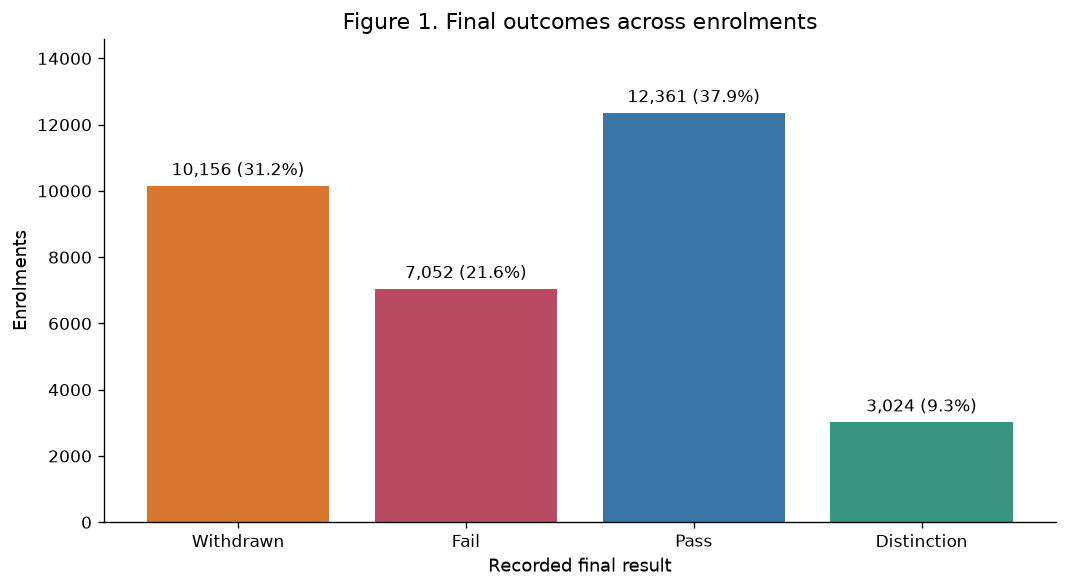

In [11]:
outcome_summary = analysis["final_result"].value_counts().reindex(OUTCOMES).rename("enrolments").to_frame()
outcome_summary["percent"] = 100 * outcome_summary["enrolments"] / len(analysis)
display(outcome_summary.round(2))
fig, ax = plt.subplots()
bars = ax.bar(OUTCOMES, outcome_summary["enrolments"], color=OUTCOME_COLORS)
ax.bar_label(bars, labels=[f"{n:,} ({p:.1f}%)" for n, p in outcome_summary.itertuples(index=False)], padding=4, fontsize=10)
ax.set(title="Figure 1. Final outcomes across enrolments", ylabel="Enrolments", xlabel="Recorded final result")
ax.set_ylim(0, outcome_summary["enrolments"].max() * 1.18)
fig.tight_layout()
plt.show()

### Figure 2. Distribution of recorded engagement

The histogram includes all enrolments, including zeros. Its x-axis is **the natural logarithm of one plus total recorded clicks**, not raw clicks. Summary statistics remain in original click units, and the marked median helps describe a distribution whose mean is pulled upward by its long upper tail.

,count,mean,std,min,25%,50%,75%,95%,99%,max
total_clicks,32593.0,1215.14,1692.60,0.0,142.0,602.0,1585.0,4568.0,7785.04,24139.0
active_days,32593.0,55.48,54.52,0.0,11.0,40.0,85.0,166.0,223.00,286.0
early_clicks,32593.0,250.50,334.65,0.0,33.0,144.0,342.0,865.0,1537.32,6440.0
early_active_days,32593.0,9.80,7.98,0.0,3.0,8.0,15.0,25.0,29.00,30.0
prestart_clicks,32593.0,65.90,129.25,0.0,0.0,19.0,76.0,285.0,602.08,3731.0


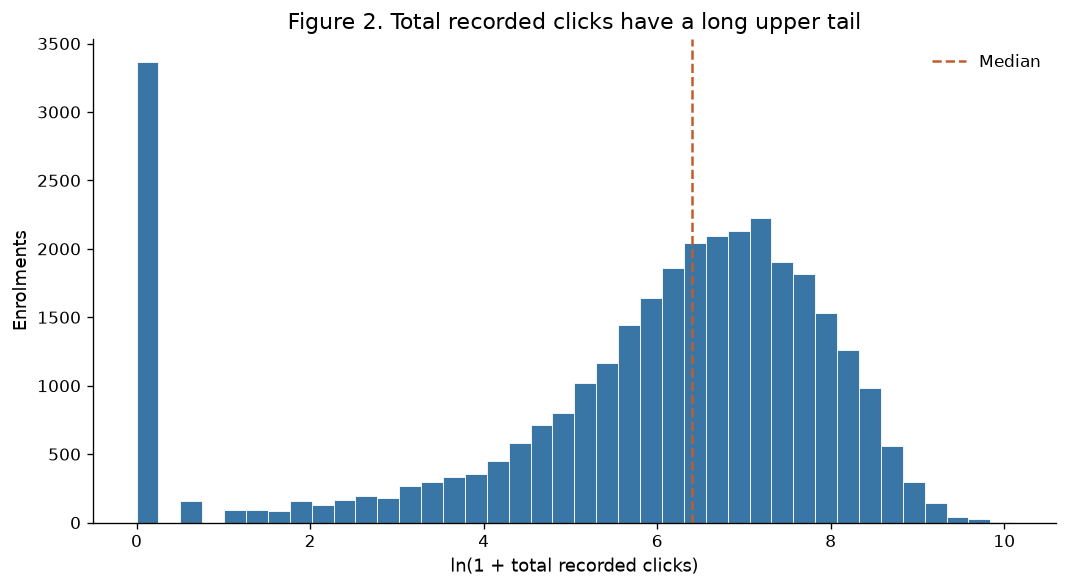

In [12]:
engagement_summary = analysis[["total_clicks", "active_days", "early_clicks", "early_active_days", "prestart_clicks"]].describe(percentiles=[.25, .5, .75, .95, .99]).T
display(engagement_summary.round(2))
fig, ax = plt.subplots()
ax.hist(np.log1p(analysis["total_clicks"]), bins=40, color="#3975A5", edgecolor="white", linewidth=.5)
ax.axvline(np.log1p(analysis["total_clicks"].median()), color="#C15D2D", linestyle="--", label="Median")
ax.set(title="Figure 2. Total recorded clicks have a long upper tail", xlabel="ln(1 + total recorded clicks)", ylabel="Enrolments")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### Figure 3. Early recorded engagement and final outcome

Boxplots compare days 0–29 using a logarithmic transformation. Boxes span the middle 50%, lines mark medians, whiskers extend to 1.5×IQR **on the transformed scale**, and all farther points are shown. The table reports raw clicks and zero-activity shares.

These differences are associations: early withdrawal itself removes opportunities to click, and course design or access may affect both recorded activity and outcome. The additional table restricted to enrolments with no recorded unregistration before day 30 is a descriptive sensitivity check, not a causal adjustment; its selection also changes the population.

,enrolments,median_early_clicks,mean_early_clicks,median_early_days,zero_early_percent,mean_total_clicks
final_result,,,,,,
Withdrawn,10156,37.5,135.94,3.0,36.90,313.95
Fail,7052,106.0,184.31,7.0,9.83,651.85
Pass,12361,228.0,333.57,12.0,1.50,1921.81
Distinction,3024,316.5,450.06,15.0,0.93,2666.76


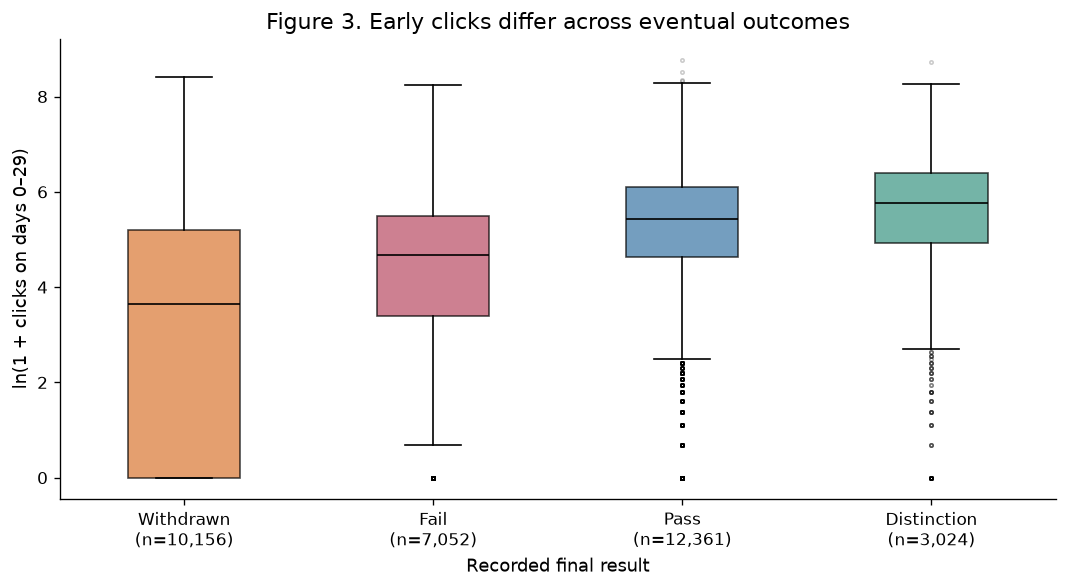

,enrolments,median_early_clicks
final_result,,
Withdrawn,5097,146.0
Fail,7044,107.0
Pass,12361,228.0
Distinction,3024,316.5


Recorded unregistration before day 30: 5067


In [13]:
early_summary = analysis.groupby("final_result", observed=True).agg(
    enrolments=("id_student", "size"), median_early_clicks=("early_clicks", "median"),
    mean_early_clicks=("early_clicks", "mean"), median_early_days=("early_active_days", "median"),
    zero_early_percent=("no_early_recorded_activity", lambda s: 100*s.mean()),
    mean_total_clicks=("total_clicks", "mean"),
).reindex(OUTCOMES)
display(early_summary.round(2))
fig, ax = plt.subplots()
box_data = [np.log1p(analysis.loc[analysis["final_result"].eq(o), "early_clicks"]) for o in OUTCOMES]
boxes = ax.boxplot(box_data, patch_artist=True, showfliers=True,
                  flierprops={"markersize": 2, "alpha": .2}, medianprops={"color": "black"})
for box, color in zip(boxes["boxes"], OUTCOME_COLORS):
    box.set_facecolor(color)
    box.set_alpha(.7)
ax.set_xticks(range(1, 5), [f"{o}\n(n={int(early_summary.loc[o, 'enrolments']):,})" for o in OUTCOMES])
ax.set(title="Figure 3. Early clicks differ across eventual outcomes", ylabel="ln(1 + clicks on days 0–29)", xlabel="Recorded final result")
fig.tight_layout()
plt.show()

observed_at_day30 = analysis["date_unregistration"].isna() | analysis["date_unregistration"].ge(30)
display(analysis.loc[observed_at_day30].groupby("final_result", observed=True).agg(
    enrolments=("id_student", "size"), median_early_clicks=("early_clicks", "median")
).reindex(OUTCOMES))
print("Recorded unregistration before day 30:", int((~observed_at_day30).sum()))

### Figure 4. Equity: outcome rates by area deprivation

IMD bands are shown in their natural order, from **most deprived (0–10%)** to **least deprived (90–100%)**; the `Missing` group is displayed separately at the end and has no deprivation rank. The points show observed rates, not a fitted trend or independent-sample confidence interval. The table supplies every denominator and includes failure as well as withdrawal.

Group differences are associations, not causes. IMD is area-level, and geography, module choice, support, access, or measurement could explain the gap; it cannot establish an individual's resources or ability. The disability cross-tab below is also descriptive: declaration is not a complete measure of disability or support needs, and group differences may reflect course composition or accessibility.

,enrolments,median_early_clicks,pass_percent,withdrawal_percent,fail_percent
imd_band,,,,,
0-10%,3311,101.0,35.16,37.18,27.67
10-20%,3516,114.0,38.62,35.44,25.94
20-30%,3654,121.0,40.75,36.15,23.10
30-40%,3539,143.0,46.91,30.94,22.15
40-50%,3256,131.0,46.59,32.00,21.41
50-60%,3124,146.0,48.78,28.78,22.44
60-70%,2905,164.0,51.91,29.57,18.52
70-80%,2879,165.0,51.51,27.68,20.81
80-90%,2762,159.0,54.06,28.02,17.92


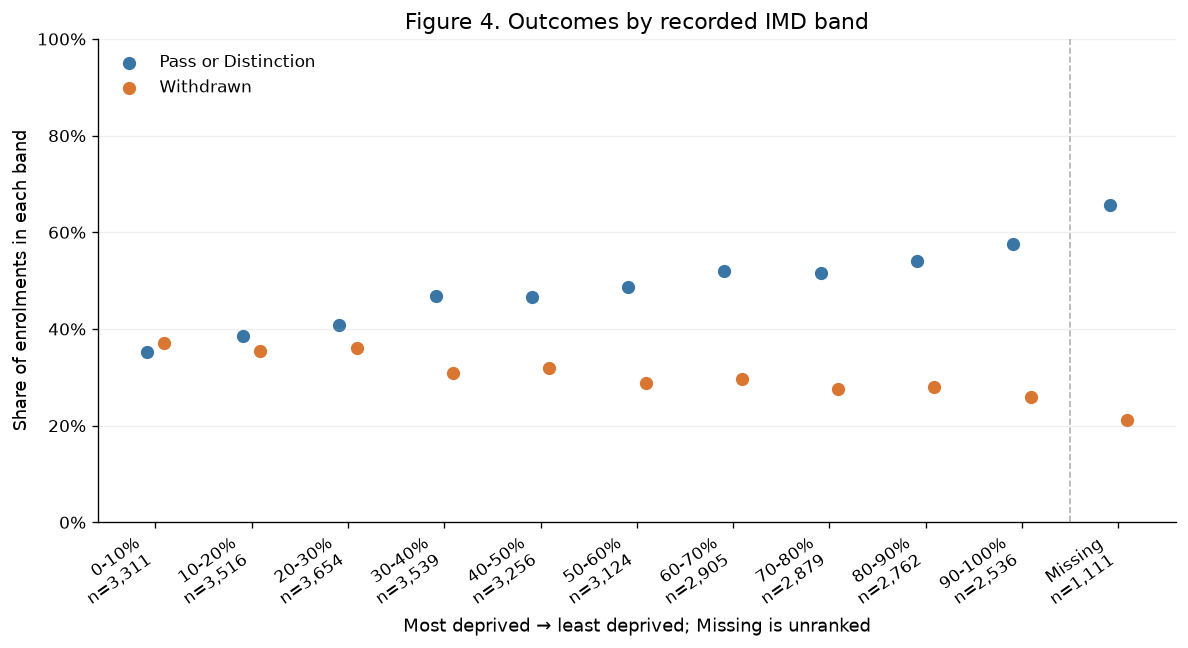

final_result,Withdrawn,Fail,Pass,Distinction,enrolments
disability,,,,,
N,8911,6340,11377,2801,29429
Y,1245,712,984,223,3164


final_result,Withdrawn,Fail,Pass,Distinction
disability,,,,
N,30.28,21.54,38.66,9.52
Y,39.35,22.50,31.10,7.05


In [14]:
imd_summary = analysis.groupby("imd_band", observed=False).agg(
    enrolments=("id_student", "size"), pass_rate=("passed", "mean"),
    withdrawal_rate=("withdrew", "mean"), fail_rate=("failed", "mean"),
    median_early_clicks=("early_clicks", "median"),
)
display(imd_summary.assign(
    pass_percent=100*imd_summary["pass_rate"], withdrawal_percent=100*imd_summary["withdrawal_rate"],
    fail_percent=100*imd_summary["fail_rate"],
).drop(columns=["pass_rate", "withdrawal_rate", "fail_rate"]).round(2))
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(imd_summary))
ax.scatter(x-.09, imd_summary["pass_rate"], label="Pass or Distinction", color="#3975A5", s=48)
ax.scatter(x+.09, imd_summary["withdrawal_rate"], label="Withdrawn", color="#D97732", s=48)
ax.axvline(9.5, color="0.7", linestyle="--", linewidth=1)
ax.set_xticks(x, [f"{band}\nn={int(n):,}" for band, n in imd_summary["enrolments"].items()], rotation=35, ha="right")
ax.set(title="Figure 4. Outcomes by recorded IMD band", ylabel="Share of enrolments in each band", xlabel="Most deprived → least deprived; Missing is unranked", ylim=(0, 1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="y", alpha=.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

disability_counts = pd.crosstab(analysis["disability"], analysis["final_result"]).reindex(columns=OUTCOMES)
disability_percent = disability_counts.div(disability_counts.sum(axis=1), axis=0)*100
display(disability_counts.assign(enrolments=disability_counts.sum(axis=1)))
display(disability_percent.round(2))

### Figure 5. Outcome mix across modules

The heatmap uses row percentages and a fixed 0–100% colour scale, so each module's size does not determine its colour. Pass and Distinction remain separate in the figure and are combined in the summary pass rate.

These module differences are associations, not measures of causal teaching effectiveness. Different learners select different modules, and assessment design, difficulty, cohort dates, and support are not held constant. The accompanying presentation table makes the mix of course presentations visible.

,enrolments,pass_percent,withdrawal_percent
code_module,,,
AAA,748,70.99,16.84
BBB,7909,47.46,30.19
CCC,4434,37.84,44.54
DDD,6272,41.61,35.87
EEE,2934,56.24,24.61
FFF,7762,47.00,30.96
GGG,2534,59.75,11.52


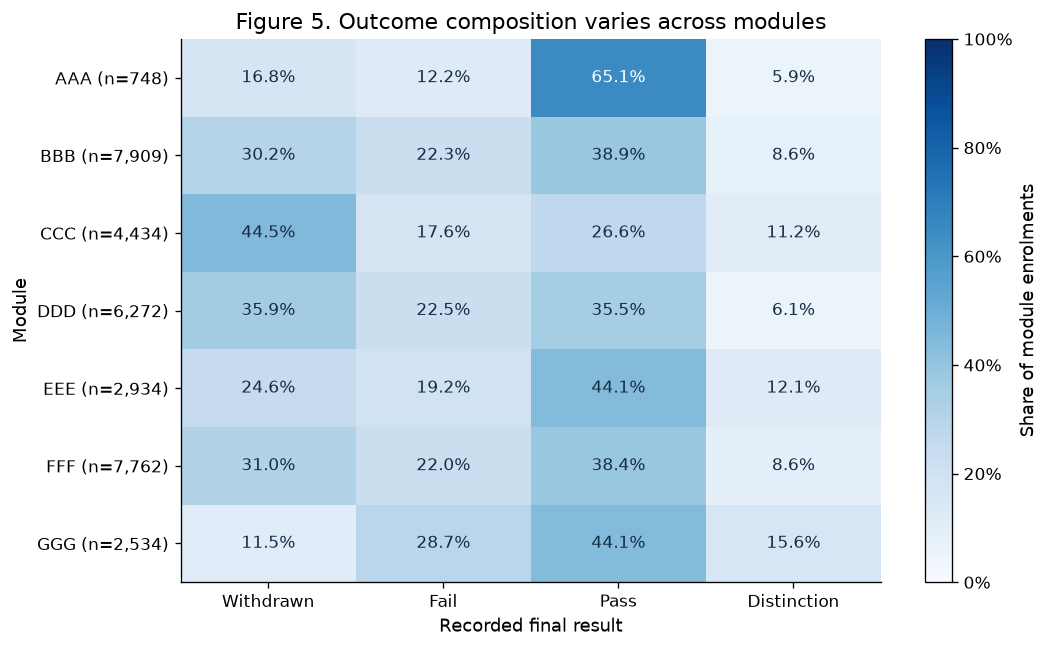

enrolments  pass_rate  withdrawal_rate
code_module code_presentation                                        
AAA         2013J                     383      0.726            0.157
            2014J                     365      0.693            0.181
BBB         2013B                    1767      0.454            0.286
            2013J                    2237      0.479            0.288
            2014B                    1613      0.451            0.304
            2014J                    2292      0.503            0.327
CCC         2014B                    1936      0.342            0.464
            2014J                    2498      0.406            0.431
DDD         2013B                    1303      0.391            0.332
            2013J                    1938      0.428            0.351
            2014B                    1228      0.390            0.399
            2014J                    1803      0.439            0.359
EEE         2013J                    1052      0.579            0.231
            2014B                     694      0.514            0.249
            2014J                    1188      0.576            0.258
FFF         2013B                    1614      0.485            0.255
            2013J                    2283      0.480            0.296
            2014B                    1500      0.436            0.308
            2014J                    2365      0.472            0.362
GGG         2013J                     952      0.622            0.069
            2014B                     833      0.574            0.120
            2014J                     749      0.593            0.168

In [15]:
module_counts = pd.crosstab(analysis["code_module"], analysis["final_result"]).reindex(columns=OUTCOMES)
module_proportions = module_counts.div(module_counts.sum(axis=1), axis=0)
module_summary = analysis.groupby("code_module", observed=True).agg(
    enrolments=("id_student", "size"), pass_rate=("passed", "mean"), withdrawal_rate=("withdrew", "mean")
)
display(module_summary.assign(pass_percent=100*module_summary["pass_rate"], withdrawal_percent=100*module_summary["withdrawal_rate"]).drop(columns=["pass_rate", "withdrawal_rate"]).round(2))
fig, ax = plt.subplots(figsize=(9, 5.5))
heat = ax.imshow(module_proportions, vmin=0, vmax=1, cmap="Blues", aspect="auto")
for i in range(len(module_proportions)):
    for j in range(len(OUTCOMES)):
        value = module_proportions.iloc[i, j]
        ax.text(j, i, f"{value:.1%}", ha="center", va="center", color="white" if value > .5 else "#172B45")
ax.set_xticks(range(4), OUTCOMES)
ax.set_yticks(range(len(module_counts)), [f"{m} (n={int(n):,})" for m, n in module_counts.sum(axis=1).items()])
ax.set(title="Figure 5. Outcome composition varies across modules", xlabel="Recorded final result", ylabel="Module")
fig.colorbar(heat, ax=ax, format=PercentFormatter(1), label="Share of module enrolments")
fig.tight_layout()
plt.show()
presentation_summary = analysis.groupby(COURSE_KEYS, observed=True).agg(
    enrolments=("id_student", "size"), pass_rate=("passed", "mean"), withdrawal_rate=("withdrew", "mean")
)
display(presentation_summary.round(3))

### Figure 6. Recorded engagement over teaching time

Weekly totals cover **days 0–209 (30 full weeks)**, a common window shorter than every presentation in these files. Week 1 is days 0–6. All course/week combinations are included, with zero for a week with no recorded clicks. Each total is divided by that presentation's **original enrolment count**, including students who withdraw; the denominator does not shrink to only active users.

A separate line per module averages its presentation rates using enrolment counts as weights. Differences and changes are descriptive: assignment deadlines, learning design, access and withdrawal can alter click volume. Falling clicks cannot alone establish falling motivation or learning, and different module curves do not identify a causal module effect.

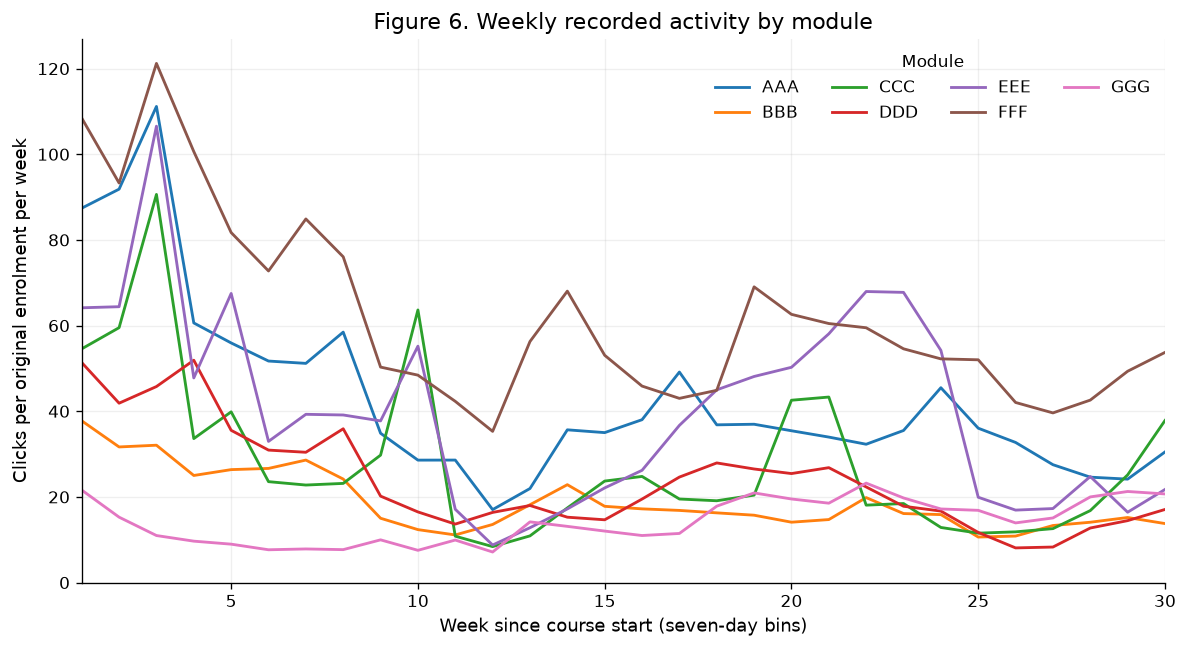

week,1,10,20,30
code_module,,,,
AAA,87.42,28.59,35.45,30.50
BBB,37.77,12.37,14.10,13.78
CCC,54.57,63.65,42.58,37.85
DDD,51.37,16.50,25.46,17.07
EEE,64.16,55.20,50.27,21.74
FFF,108.45,48.43,62.63,53.74
GGG,21.60,7.54,19.52,20.70


In [16]:
N_WEEKS = 30
assert tables["courses"]["module_presentation_length"].min() >= 7*N_WEEKS
weekly_source = course_day.loc[course_day["date"].between(0, 7*N_WEEKS-1)].copy()
weekly_source["week"] = weekly_source["date"] // 7 + 1
weekly_counts = weekly_source.groupby(COURSE_KEYS + ["week"], observed=True)["sum_click"].sum().rename("clicks").reset_index()
course_enrolments = analysis.groupby(COURSE_KEYS, observed=True).size().rename("enrolments").reset_index()
course_week_grid = course_enrolments.merge(pd.DataFrame({"week": np.arange(1, N_WEEKS+1)}), how="cross")
weekly = course_week_grid.merge(weekly_counts, on=COURSE_KEYS+["week"], how="left", validate="one_to_one")
weekly["clicks"] = weekly["clicks"].fillna(0)
weekly["clicks_per_enrolment"] = weekly["clicks"] / weekly["enrolments"]
module_weekly = weekly.groupby(["code_module", "week"], observed=True).agg(clicks=("clicks", "sum"), enrolments=("enrolments", "sum"))
module_weekly["clicks_per_enrolment"] = module_weekly["clicks"] / module_weekly["enrolments"]
fig, ax = plt.subplots(figsize=(10, 5.5))
for module, frame in module_weekly.reset_index().groupby("code_module", observed=True):
    ax.plot(frame["week"], frame["clicks_per_enrolment"], label=module, linewidth=1.7)
ax.set(title="Figure 6. Weekly recorded activity by module", xlabel="Week since course start (seven-day bins)", ylabel="Clicks per original enrolment per week", xlim=(1, N_WEEKS), ylim=(0, None))
ax.grid(alpha=.2)
ax.legend(title="Module", ncol=4, frameon=False)
fig.tight_layout()
plt.show()
display(module_weekly["clicks_per_enrolment"].unstack("week")[[1, 10, 20, 30]].round(2))

### Figure 7. Previous attempts and pass rate

The table retains every observed attempt count; the figure pools two or more previous attempts to avoid giving tiny groups the same visual emphasis as common groups. Groups remain ordered. A pass is Pass or Distinction, and the denominator includes withdrawal.

This is an association, not an effect of retrying. Prior difficulty, interruptions, support, module mix, and selection into another attempt can all affect the comparison. The same person can also contribute more than one enrolment, so no independent-sample significance test is claimed.

,enrolments,pass_rate,withdrawal_rate
num_of_prev_attempts,,,
0,28421,0.493,0.306
1,3299,0.346,0.349
2,675,0.284,0.366
3,142,0.225,0.373
4,39,0.333,0.359
5,13,0.154,0.385
6,4,0.250,0.500


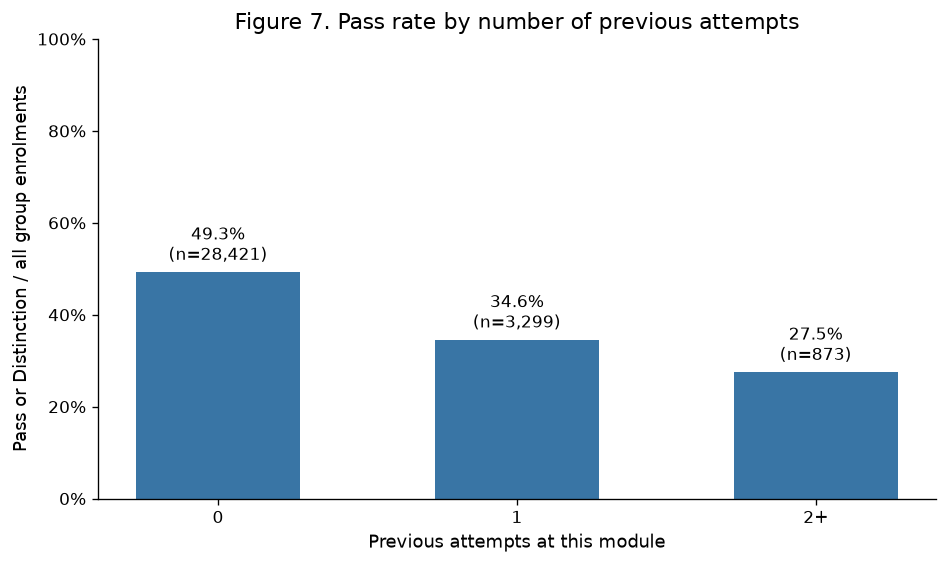

In [17]:
attempt_detail = analysis.groupby("num_of_prev_attempts", observed=True).agg(
    enrolments=("id_student", "size"), pass_rate=("passed", "mean"), withdrawal_rate=("withdrew", "mean")
)
display(attempt_detail.round(3))
analysis["previous_attempt_group"] = pd.Categorical(
    np.select([analysis["num_of_prev_attempts"].eq(0), analysis["num_of_prev_attempts"].eq(1)], ["0", "1"], default="2+"),
    categories=["0", "1", "2+"], ordered=True,
)
attempt_summary = analysis.groupby("previous_attempt_group", observed=False).agg(
    enrolments=("id_student", "size"), pass_rate=("passed", "mean"), withdrawal_rate=("withdrew", "mean")
)
fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar([str(x) for x in attempt_summary.index], attempt_summary["pass_rate"], color="#3975A5", width=.55)
ax.bar_label(bars, labels=[f"{r:.1%}\n(n={int(n):,})" for n, r in attempt_summary[["enrolments", "pass_rate"]].itertuples(index=False)], padding=4)
ax.set(title="Figure 7. Pass rate by number of previous attempts", xlabel="Previous attempts at this module", ylabel="Pass or Distinction / all group enrolments", ylim=(0, 1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
fig.tight_layout()
plt.show()

## Part 4 — Five findings with a social lens

All rates below refer to enrolments; the same person can appear in more than one enrolment. These are descriptions of the supplied files, not population estimates or causal effects.

1. **Recorded engagement is strongly concentrated in a long upper tail.** The median is **602 total clicks**, compared with a mean of **1,215.1**; the **2,503 enrolments (7.68%)** above the IQR fence account for **36.4%** of recorded clicks. **Evidence:** Figure 2, the engagement summary, and the Part 2 outlier table. **What this cannot tell us:** high click counts are not measures of better learning; resource design, repeated log records, and time enrolled can affect the totals.

2. **Higher early recorded engagement is associated with more favourable eventual outcomes.** Median clicks on days 0–29 are **37.5 for Withdrawn**, **106 for Fail**, **228 for Pass**, and **316.5 for Distinction**. Zero early recorded clicks occur in **36.9%** of Withdrawn enrolments and **1.5%** of Pass enrolments. **Evidence:** Figure 3 and its raw-unit summary (group sizes: 10,156; 7,052; 12,361; 3,024). **What this cannot tell us:** this is association, not evidence that increasing clicks causes passing; early withdrawal, access barriers, prior preparation, and course design can jointly influence engagement and outcomes.

3. **The observed pass rate differs substantially across the deprivation extremes.** Pass or Distinction occurs in **35.2%** of the **3,311** enrolments in IMD **0–10%**, versus **57.5%** of the **2,536** in **90–100%**: a **22.4 percentage-point difference**. Withdrawal rates are **37.2%** and **25.9%**, respectively. **Evidence:** Figure 4 and the IMD summary; the 1,111 missing-IMD enrolments remain a separate group. **What this cannot tell us:** these are unadjusted associations, not causal effects of deprivation or evidence about individual ability. IMD measures areas, and module mix, geography, support, and access can influence the comparison. The uneven missingness also limits interpretation.

4. **Module outcome differences are large enough that pooled comparisons need context.** Module **AAA** has a **71.0%** pass rate (**n=748**), whereas **CCC** has **37.8%** (**n=4,434**). Withdrawal is **44.5%** in CCC versus **11.5%** in GGG (**n=2,534**). **Evidence:** Figure 5, its module table, and the 22-presentation summary. **What this cannot tell us:** these associations do not rank causal teaching effectiveness; student selection, assessment design, access, cohort mix, and course difficulty are not controlled. They motivate examining equity and engagement within comparable course contexts.

5. **Enrolments with previous attempts have lower observed pass rates.** The pass rate is **49.3%** with **no previous attempts (n=28,421)**, **34.6%** with **one (n=3,299)**, and **27.5%** with **two or more (n=873)**. **Evidence:** Figure 7 and the exact-attempt summary. **What this cannot tell us:** this is association, not an adverse causal effect of retrying; prior difficulties, interruptions, differences in support, module choice, and selection into another attempt may explain it. Repeated enrolments from the same people also mean the groups are not independent random samples.

## Part 5 — Reproducibility and reflection

### Reproduce this report

1. Place `a1_sample.ipynb` beside `content/`, containing `studentInfo.csv`, `studentRegistration.csv`, `studentVle.csv`, `vle.csv`, `assessments.csv`, `studentAssessment.csv`, and `courses.csv`.
2. Open a Python kernel with NumPy, pandas, Matplotlib, and IPython available. The first cell reports the versions used, and `DATA_DIR` is the only path to change for another data location.
3. Choose **Restart Kernel and Run All**. A complete run loads the original files, builds `analysis`, checks keys and aggregation, and regenerates every table and figure. The saved outputs in this sample come from an actual clean-kernel run.
4. The fixed seed is 42, although no random subsampling or stochastic model is used. Source CSVs are never overwritten. File sizes, parsed shapes, and package versions are printed for comparison with another run.

This is a descriptive report, not a prediction pipeline. Final outcomes, unregistration dates, full-course clicks, and full-course assessment means contain information unavailable early in a course. They must not be used as if they were prospective day-30 predictors. A later predictive study would need a defined observation cutoff, a label horizon, and student-aware validation splits.

### Reflection

The most consequential decisions were recognizing the `?` missing-value marker, preserving enrolment-level keys, and separating unknown values from zero recorded activity. A syntactically successful join or an attractive chart would not compensate for errors in those decisions. Keeping outliers and presenting both raw summaries and transformed distributions makes the effect of skew visible without deciding that high activity must be wrong.

The equity analysis is useful for identifying questions about support and accessibility, but it cannot explain why gaps exist or label individuals as less capable. Better information on resource accessibility, offline learning, assessment coverage, and support received would improve interpretation; student consultation and comparisons within the same course presentation would also help. Missingness, course composition, and repeated enrolments would need more careful treatment before generalization or causal claims.

### Completion checks

The notebook includes all seven table inspections, all source-column attribute types, explicit key and missingness decisions, date/outlier audits, seven varied figures, and five findings with evidence and caveats. The final validation cell below confirms the core numerical invariants from the executed analysis.

In [18]:
assert len(analysis) == len(tables["studentInfo"])
assert not analysis.duplicated(KEYS).any()
assert outcome_summary["enrolments"].sum() == len(analysis)
assert imd_summary["enrolments"].sum() == len(analysis)
assert module_summary["enrolments"].sum() == len(analysis)
assert attempt_summary["enrolments"].sum() == len(analysis)
assert analysis["total_clicks"].sum() == tables["studentVle"]["sum_click"].sum()
assert len(attr_types) == sum(t.shape[1] for t in tables.values())
print(f"All checks passed: {len(analysis):,} enrolments, "
      f"{analysis['id_student'].nunique():,} unique students, "
      f"{len(attr_types)} source columns classified, and seven figures generated.")

All checks passed: 32,593 enrolments, 28,785 unique students, 43 source columns classified, and seven figures generated.


### Generative-AI use disclosure

This sample notebook was created with **OpenAI Codex**, which read the assignment outline, starter notebook, supplied lecture slides, example notebooks, and dataset documentation; drafted the code and explanations; inspected the supplied data; and executed and checked the notebook. AI assistance included choosing visualizations, documenting cleaning decisions, and drafting the findings and reflection. The calculations use the actual supplied OULAD files, not fabricated data. The notebook includes source attribution and explicitly separates evidence from interpretation.

This disclosure describes the assistance used to create this sample; it does not claim that a student has independently reviewed or understood it. Anyone adapting it for submission must review the analysis, be able to explain every submitted line, and accurately describe their own use of AI, as required by the assignment.